In [1]:
import keras
import tensorflow as tf
from keras import layers
import matplotlib.pyplot as plt
import os
from keras import ops
import pandas as pd
import numpy as np

2025-08-03 13:28:57.306506: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1754206137.322273   58604 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1754206137.327064   58604 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1754206137.339769   58604 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754206137.339786   58604 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1754206137.339788   58604 computation_placer.cc:177] computation placer alr

In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = (64, 64)
LATENT_DIM = 128
CHANNELS = 3
# We now use 4 classes based on the combination of Male and Smiling attributes
NUM_CLASSES = 4

In [4]:
attr_path = os.path.join("celeba_gan", "list_attr_celeba.csv")
df_attr = pd.read_csv(attr_path, sep=',', header=0)

# Extract the relevant attributes: 'Male' and 'Smiling'
# We map [-1, 1] to [0, 1] for easier class mapping
male_labels = ((df_attr['Male'] + 1) // 2).to_numpy()
smiling_labels = ((df_attr['Smiling'] + 1) // 2).to_numpy()

In [5]:
# Combine attributes into 4 classes:
# 0: Female, Not Smiling
# 1: Female, Smiling
# 2: Male, Not Smiling
# 3: Male, Smiling
combined_labels = male_labels * 2 + smiling_labels
labels = tf.one_hot(combined_labels, NUM_CLASSES)

2025-08-03 13:29:00.225697: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1754206140.225865   58604 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7127 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1070, pci bus id: 0000:01:00.0, compute capability: 6.1


In [6]:
# Get image paths from the 'image_id' column of the CSV
image_dir = os.path.join("celeba_gan", "img_align_celeba/img_align_celeba")
image_paths = [os.path.join(image_dir, fname) for fname in df_attr['image_id']]

In [7]:
# Create the dataset from slices of paths and labels
dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))

# Define the image loading and preprocessing function
def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=CHANNELS)
    image = tf.image.resize(image, [IMAGE_SIZE[0], IMAGE_SIZE[1]])
    # Normalize images to the range [-1, 1]
    image = (tf.cast(image, tf.float32) - 127.5) / 127.5
    return image, label

# Map, shuffle, and batch the dataset
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
dataset = dataset.take(500)

In [8]:
# --- 3. Create Conditional Discriminator ---
discriminator_in_channels = CHANNELS + NUM_CLASSES

discriminator = keras.Sequential(
    [
        keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], discriminator_in_channels)),
        layers.Conv2D(64, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2D(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Flatten(),
        layers.Dropout(0.2),
        layers.Dense(1),
    ],
    name="discriminator",
)

In [9]:
# --- 4. Create Conditional Generator ---
generator_in_channels = LATENT_DIM + NUM_CLASSES

generator = keras.Sequential(
    [
        keras.Input(shape=(generator_in_channels,)),
        layers.Dense(8 * 8 * 128),
        layers.Reshape((8, 8, 128)),
        layers.Conv2DTranspose(128, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2DTranspose(256, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2DTranspose(512, kernel_size=4, strides=2, padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Conv2D(3, kernel_size=5, padding="same", activation="tanh"),
    ],
    name="generator",
)

In [10]:
# --- 5. Create the ConditionalGAN Model ---
class ConditionalGAN(keras.Model):
    def __init__(self, discriminator, generator, latent_dim, num_classes):
        super().__init__()
        self.discriminator = discriminator
        self.generator = generator
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.gen_loss_tracker = keras.metrics.Mean(name="generator_loss")
        self.disc_loss_tracker = keras.metrics.Mean(name="discriminator_loss")

    @property
    def metrics(self):
        return [self.gen_loss_tracker, self.disc_loss_tracker]

    def compile(self, d_optimizer, g_optimizer, loss_fn):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        self.loss_fn = loss_fn

    def train_step(self, data):
        real_images, one_hot_labels = data
        batch_size = ops.shape(real_images)[0]

        image_one_hot_labels = ops.reshape(
            one_hot_labels, (batch_size, 1, 1, self.num_classes)
        )
        image_one_hot_labels = tf.tile(
            image_one_hot_labels, [1, IMAGE_SIZE[0], IMAGE_SIZE[1], 1]
        )

        random_latent_vectors = keras.random.normal(shape=(batch_size, self.latent_dim))
        random_vector_labels = ops.concatenate([random_latent_vectors, one_hot_labels], axis=1)
        generated_images = self.generator(random_vector_labels)

        fake_image_and_labels = ops.concatenate([generated_images, image_one_hot_labels], -1)
        real_image_and_labels = ops.concatenate([real_images, image_one_hot_labels], -1)
        combined_images = ops.concatenate([fake_image_and_labels, real_image_and_labels], axis=0)
        labels = ops.concatenate([ops.ones((batch_size, 1)), ops.zeros((batch_size, 1))], axis=0)

        with tf.GradientTape() as tape:
            predictions = self.discriminator(combined_images)
            d_loss = self.loss_fn(labels, predictions)
        grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
        self.d_optimizer.apply_gradients(zip(grads, self.discriminator.trainable_weights))

        random_latent_vectors = keras.random.normal(shape=(batch_size, self.latent_dim))
        random_vector_labels = ops.concatenate([random_latent_vectors, one_hot_labels], axis=1)
        misleading_labels = ops.zeros((batch_size, 1))

        with tf.GradientTape() as tape:
            generated_images = self.generator(random_vector_labels)
            fake_image_and_labels = ops.concatenate([generated_images, image_one_hot_labels], -1)
            predictions = self.discriminator(fake_image_and_labels)
            g_loss = self.loss_fn(misleading_labels, predictions)
        grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(grads, self.generator.trainable_weights))

        self.gen_loss_tracker.update_state(g_loss)
        self.disc_loss_tracker.update_state(d_loss)
        return {
            "d_loss": self.disc_loss_tracker.result(),
            "g_loss": self.gen_loss_tracker.result(),
        }

In [11]:
# --- 6. Callback for monitoring training ---
class GANMonitor(keras.callbacks.Callback):
    def __init__(self, num_img=3, latent_dim=128, num_classes=4):
        self.num_img = num_img
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.generated_images = []

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0:
            epoch_images = []
            for class_idx in range(self.num_classes):
                random_latent_vectors = tf.random.normal(shape=(self.num_img, self.latent_dim))
                label = tf.one_hot([class_idx] * self.num_img, self.num_classes)
                random_vector_labels = tf.concat([random_latent_vectors, label], axis=1)
                generated_images = self.model.generator(random_vector_labels, training=False)
                generated_images = ((generated_images + 1) / 2 * 255).numpy().astype("uint8")
                epoch_images.extend(generated_images)
            self.generated_images.append(np.array(epoch_images))

In [12]:
# --- 7. Compile and Train the Model ---
cgan = ConditionalGAN(
    discriminator=discriminator,
    generator=generator,
    latent_dim=LATENT_DIM,
    num_classes=NUM_CLASSES
)
cgan.compile(
    d_optimizer=keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5),
    g_optimizer=keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5),
    loss_fn=keras.losses.BinaryCrossentropy(from_logits=True),
)

monitor = GANMonitor(num_img=3, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES)

history = cgan.fit(
    dataset,
    epochs=25,
    callbacks=[monitor]
)

Epoch 1/25


I0000 00:00:1754206143.254224   58977 service.cc:152] XLA service 0x714a24006580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1754206143.254246   58977 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1070, Compute Capability 6.1
2025-08-03 13:29:03.313127: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1754206143.692428   58977 cuda_dnn.cc:529] Loaded cuDNN version 90501
2025-08-03 13:29:04.851508: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch size

500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 231ms/step - d_loss: 0.4290 - g_loss: 1.9081
Epoch 2/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 235ms/step - d_loss: 0.6367 - g_loss: 0.8926
Epoch 3/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 117s 233ms/step - d_loss: 0.6559 - g_loss: 0.8048
Epoch 4/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 235ms/step - d_loss: 0.6664 - g_loss: 0.7985
Epoch 5/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 117s 235ms/step - d_loss: 0.6664 - g_loss: 0.8079
Epoch 6/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 235ms/step - d_loss: 0.6637 - g_loss: 0.8004
Epoch 7/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 117s 234ms/step - d_loss: 0.6559 - g_loss: 0.8080
Epoch 8/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 117s 233ms/step - d_loss: 0.6676 - g_loss: 0.7906
Epoch 9/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 236ms/step - d_loss: 0.6658 - g_loss: 0.7911
Epoch 10/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 117s 233ms/step - d_loss: 0.6667 - g_loss: 0.7918
Epoch 11/25
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 236ms/step - d_loss: 0.6691 - g_loss: 0.7906
Epoch 12/25
500/500

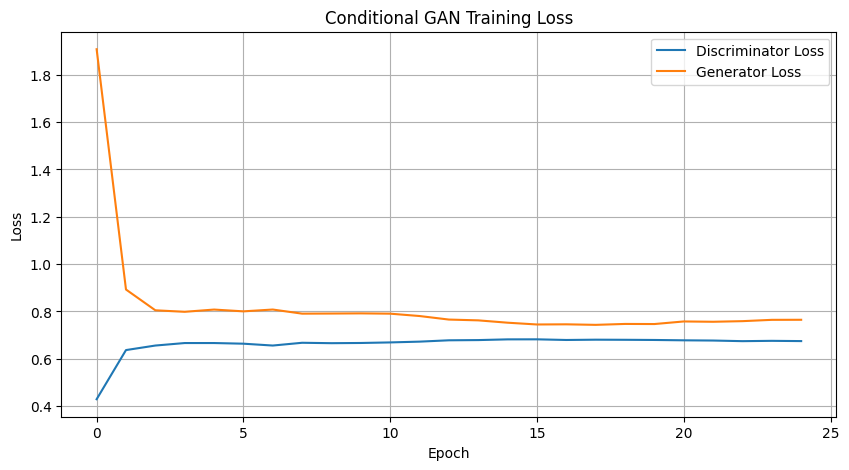

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['d_loss'], label='Discriminator Loss')
plt.plot(history.history['g_loss'], label='Generator Loss')
plt.title('Conditional GAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

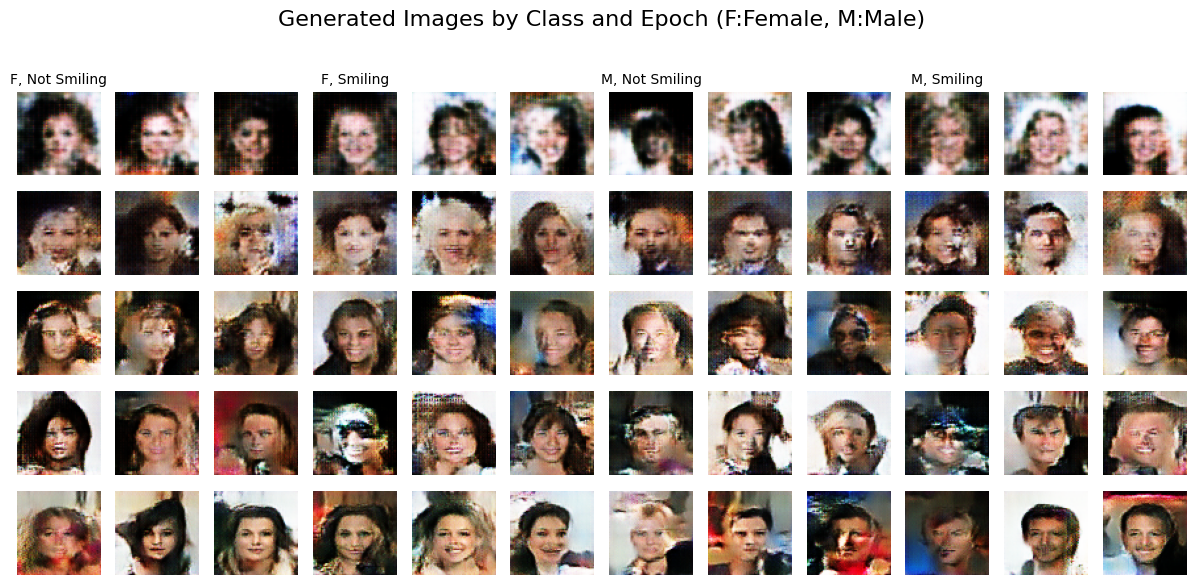

In [14]:
if monitor.generated_images:
    class_names = [
        "F, Not Smiling",
        "F, Smiling",
        "M, Not Smiling",
        "M, Smiling"
    ]
    num_epochs_saved = len(monitor.generated_images)
    # Adjust number of columns based on the new num_img
    num_cols = monitor.num_img * NUM_CLASSES 
    
    # Adjust figsize for better readability
    fig, axes = plt.subplots(num_epochs_saved, num_cols, figsize=(12, 6))
    fig.suptitle("Generated Images by Class and Epoch (F:Female, M:Male)", fontsize=16)

    for i, epoch_imgs in enumerate(monitor.generated_images):
        epoch_num = (i + 1) * 5
        for j, img in enumerate(epoch_imgs):
            # Correctly map the flat image index to the 2D axes grid
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis("off")
            
            # Add class titles only on the top row
            if i == 0 and j % monitor.num_img == 0:
                class_idx = j // monitor.num_img
                ax.set_title(class_names[class_idx], fontsize=10)

        # Add epoch labels to the left of each row
        if num_epochs_saved > 1:
            # Position the Y-label to the left of the first image of the row
            axes[i, 0].set_ylabel(f"Epoch {epoch_num}", fontsize=12)
            
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to prevent title overlap
    plt.show()